# Whakaari Dataset

This notebook builds the Whakaari case-study dataset for Cause–Trigger analysis. It combines waveform-derived hydrothermal/seismic features with weather, gas, and deformation variables on a common hourly grid.

In [3]:
import sys
from pathlib import Path

import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/whakaari"
sys.path.append(str(SRC_DIR))

from whakaari_config import (
    WHAKAARI_START,
    WHAKAARI_END,
    WHAKAARI_ERUPTION_TIME,
    TILDE_DATA_URL,
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_WAVEFORM_CONFIG,
    whakaari_observable_metadata,
)

from whakaari_geonet import (
    load_so2_flux,
    load_gnss_deformation,
    load_weather_vars,
)

from whakaari_waveform import build_waveform_dataset

from whakaari_dataset import (
    build_master_dataframe,
    prepare_raw_analysis_dataframe,
    build_final_causal_dataframe,
    save_whakaari_datasets,
    preprocessing_report,
)

from whakaari_plotting_utils import (
    WHAKAARI_ALL_COLS,
    dataset_health_report,
    plot_variable_pdfs,
    distribution_summary,
    plot_whakaari_all_variables_map,
    plot_whakaari_thesis_figures,
)

client = Client("GEONET")

BUFFER_START = (
    pd.Timestamp(WHAKAARI_START, tz="UTC") - pd.Timedelta(days=2)
).strftime("%Y-%m-%d")

## GeoNet and external data

We retrieve SO₂ flux and GNSS deformation from GeoNet/Tilde, and hourly weather variables from Open-Meteo. Antecedent Precipitation Index (API) and pressure drop are derived as hydrothermal forcing proxies.

In [4]:
so2 = load_so2_flux(
    tilde_data_base_url=TILDE_DATA_URL,
    start=BUFFER_START,
    end=WHAKAARI_END,
)

gnss = load_gnss_deformation(
    tilde_data_base_url=TILDE_DATA_URL,
    start=BUFFER_START,
    end=WHAKAARI_END,
)

weather_vars = load_weather_vars(
    lat=WHAKAARI_LAT,
    lon=WHAKAARI_LON,
    start=BUFFER_START,
    end=WHAKAARI_END,
)

## Waveform feature extraction

Waveform data from WSRZ are processed into hourly seismic features: hydrothermal tremor RMS, spectral ratio, HF event rate, and a continuous tremor-response energy variable.

In [5]:
WHAKAARI_WAVEFORM_PKL = "../data/whakaari/whakaari_waveform.pkl"

waveform_df, waveform_failures = build_waveform_dataset(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    cfg=WHAKAARI_WAVEFORM_CONFIG,
    save_path=WHAKAARI_WAVEFORM_PKL,
    overwrite=False, # True will re-download and process waveforms, False will load from pkl
)

loaded cached waveform dataset: ..\data\whakaari\whakaari_waveform.pkl


## Final hourly dataset

All variables are aligned to a common hourly timeline. Missing values are handled according to variable type, and the final dataset is saved in raw and scaled forms.

In [6]:
whakaari_master = build_master_dataframe(
    wave=waveform_df,
    weather_vars=weather_vars,
    so2=so2,
    gnss=gnss,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
)

whakaari_raw = prepare_raw_analysis_dataframe(whakaari_master)

whakaari_final = build_final_causal_dataframe(
    whakaari_raw
)

save_whakaari_datasets(
    whakaari_raw=whakaari_raw,
    whakaari_final=whakaari_final,
    output_dir="../data/whakaari",
)

## Distribution diagnostics & preprocessing summary

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 


Whakaari analysis dataset
shape: (1700, 8)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_2_5                0.000000
ratio_4p5_8_over_8_16    0.000000
event_rate_2_5           0.000000
effect_tremor_5_15       0.000000
API                      0.000000
pressure_drop            0.000000
GNSS_deformation         0.000000
SO2_flux                 0.767647
dtype: float64
Whakaari analysis dataset


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
API,1700.0,0.099261,0.196537,5.768107e-07,0.024478,1.195308,3.256516,1700,0.000000
GNSS_deformation,1700.0,0.012894,0.003075,4.500000e-03,0.013080,0.021210,-0.088004,71,0.000000
SO2_flux,395.0,4.565517,3.840615,8.449100e-02,3.446339,20.699190,1.577410,392,0.767647
effect_tremor_5_15,1700.0,0.000006,0.000056,9.023086e-07,0.000004,0.001964,31.315037,1700,0.000000
event_rate_2_5,1700.0,7.700588,7.211372,0.000000e+00,6.000000,65.000000,2.258163,45,0.000000
hydro_2_5,1700.0,0.000005,0.000082,4.953468e-07,0.000002,0.002868,31.273483,1700,0.000000
pressure_drop,1700.0,-0.001647,0.454638,-1.800000e+00,0.000000,1.800000,0.080462,57,0.000000
ratio_4p5_8_over_8_16,1700.0,1.641524,0.465380,4.959367e-01,1.741494,2.986552,-0.497299,1700,0.000000


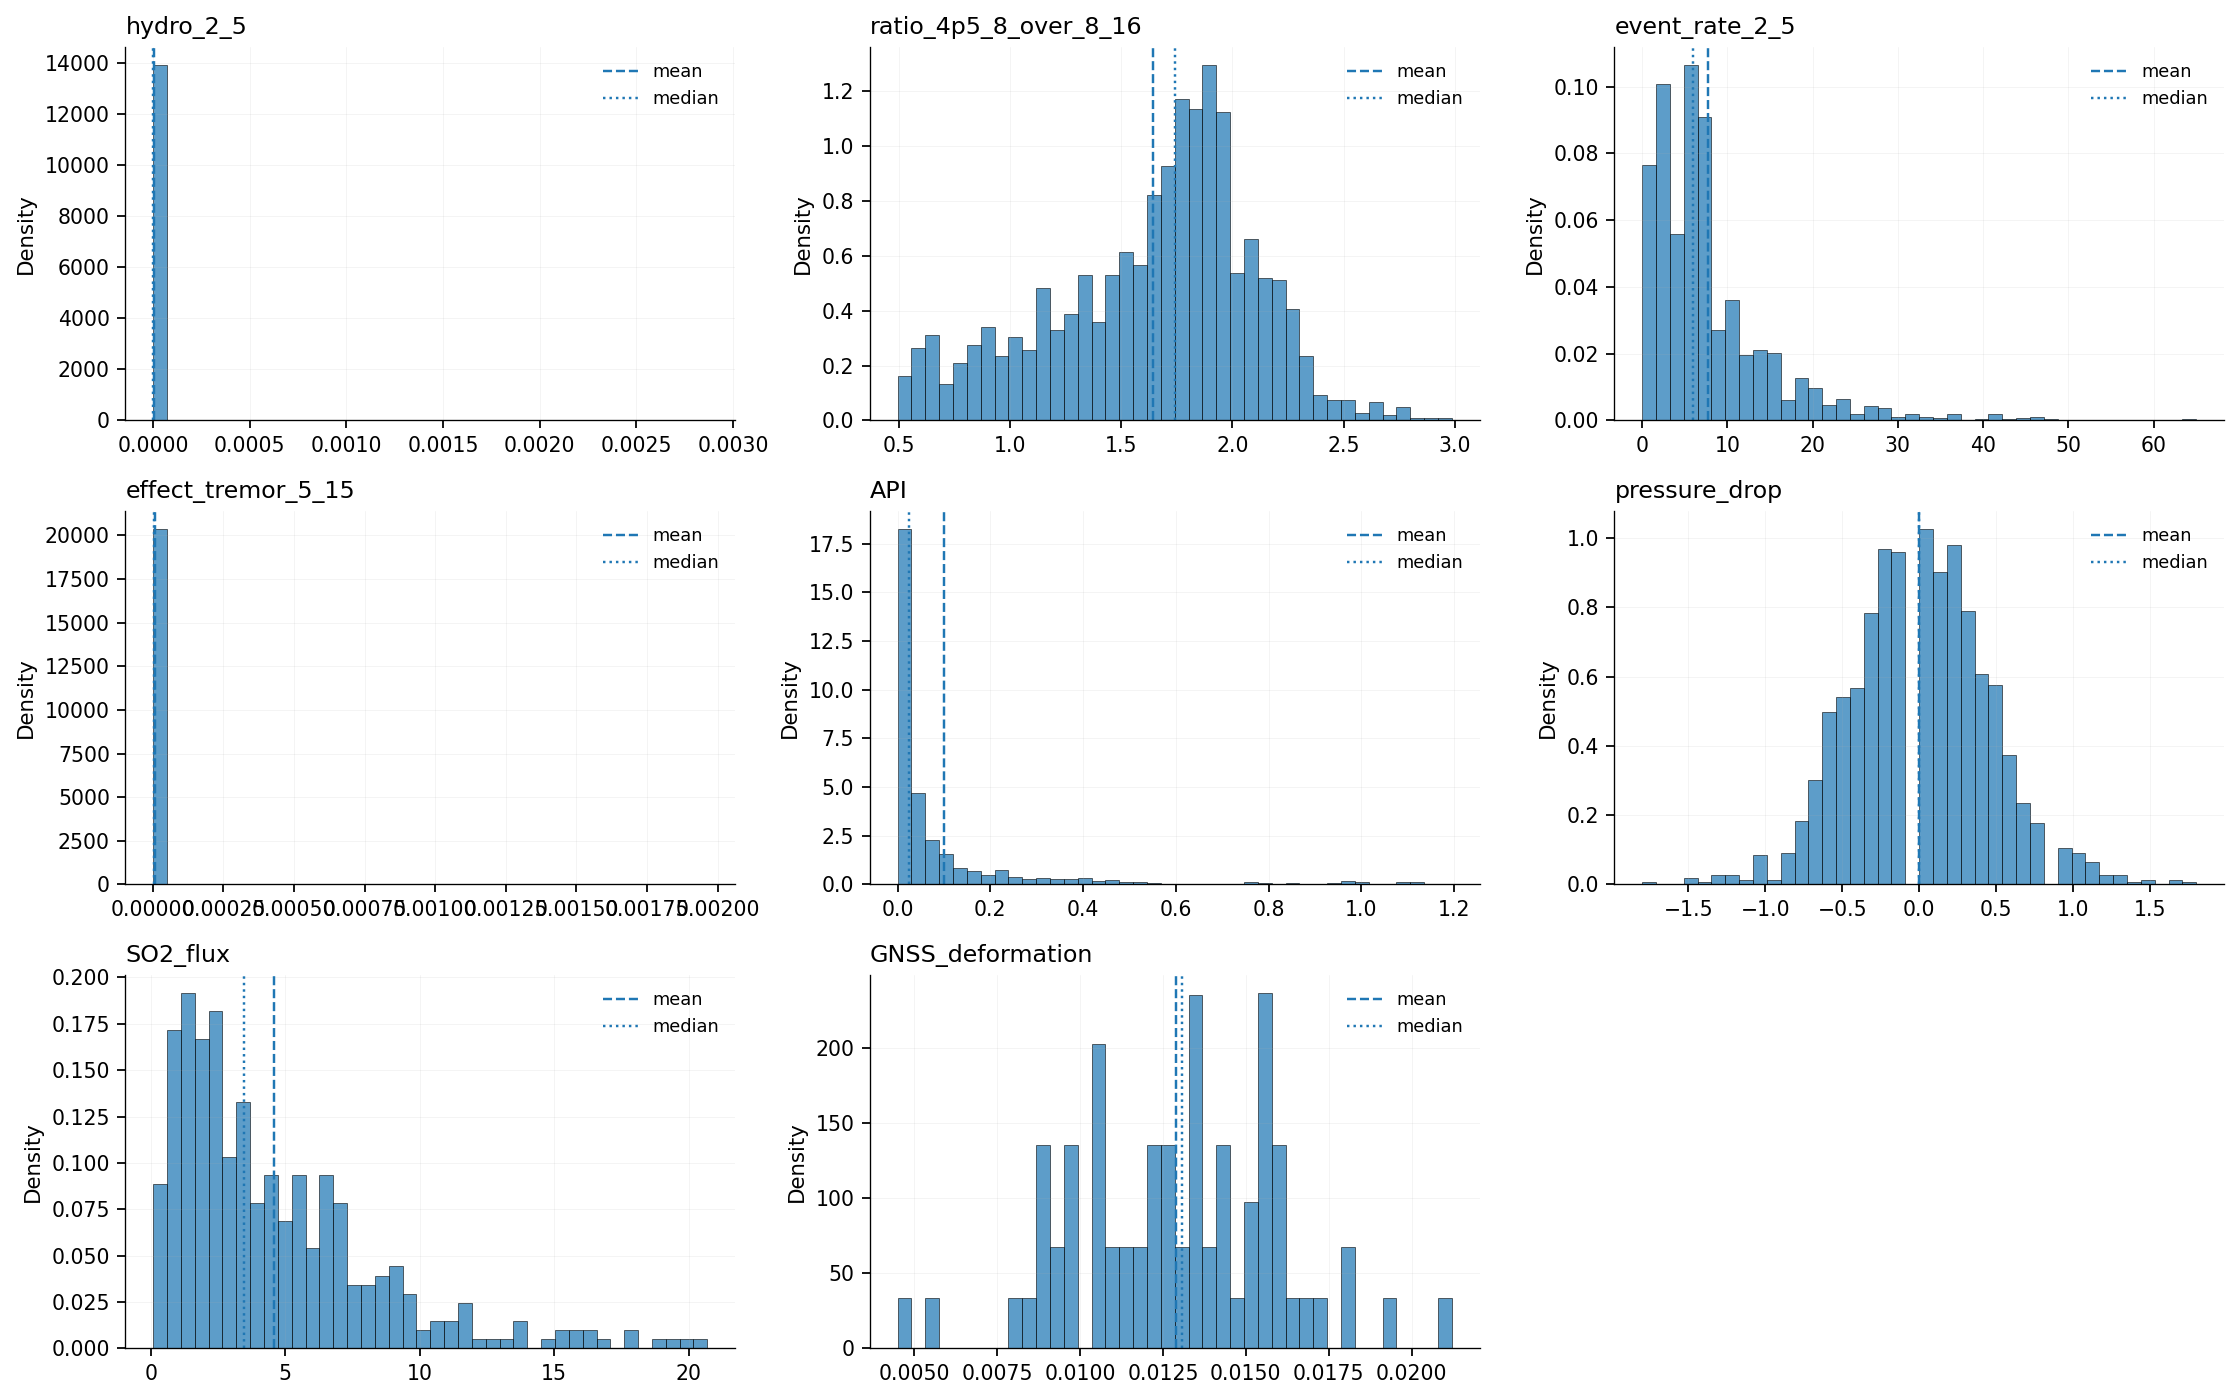

(<Figure size 2256x1440 with 9 Axes>,
 array([<Axes: title={'left': 'hydro_2_5'}, ylabel='Density'>,
        <Axes: title={'left': 'ratio_4p5_8_over_8_16'}, ylabel='Density'>,
        <Axes: title={'left': 'event_rate_2_5'}, ylabel='Density'>,
        <Axes: title={'left': 'effect_tremor_5_15'}, ylabel='Density'>,
        <Axes: title={'left': 'API'}, ylabel='Density'>,
        <Axes: title={'left': 'pressure_drop'}, ylabel='Density'>,
        <Axes: title={'left': 'SO2_flux'}, ylabel='Density'>,
        <Axes: title={'left': 'GNSS_deformation'}, ylabel='Density'>,
        <Axes: >], dtype=object))

In [7]:
dataset_health_report(whakaari_raw, "Whakaari analysis dataset")

display(distribution_summary(whakaari_raw, "Whakaari analysis dataset"))

plot_variable_pdfs(
    whakaari_raw,
    name="",
    cols=WHAKAARI_ALL_COLS,
    bins=40,
    filename="whakaari_pdf.png"
)

In [8]:
preprocessing_summary = preprocessing_report(
    rawest_df=whakaari_master,
    prepared_df=whakaari_raw,
)


Preprocessing summary
---------------------
Rows before preprocessing: 1704
Rows after preprocessing:  1700
Rows dropped:              4

Dropped timestamps:
  2019-11-18 23:00:00+00:00
  2019-11-19 00:00:00+00:00
  2019-11-19 01:00:00+00:00
  2019-11-19 02:00:00+00:00

Variables with preprocessing changes:


,variable,status,missing_before,missing_after,filled_from_nan,changed_existing,lost_by_dropped_rows
0,API,kept,0,0,0,0,4
1,GNSS_deformation,kept,0,0,0,0,4
2,SO2_flux,kept,1490,1305,184,0,3
6,pressure_drop,kept,0,0,0,0,4


## Final hourly dataset with event marker

The final variables are plotted with the eruption time marked. To assess whether the causal-analysis window and variables are physically meaningful.

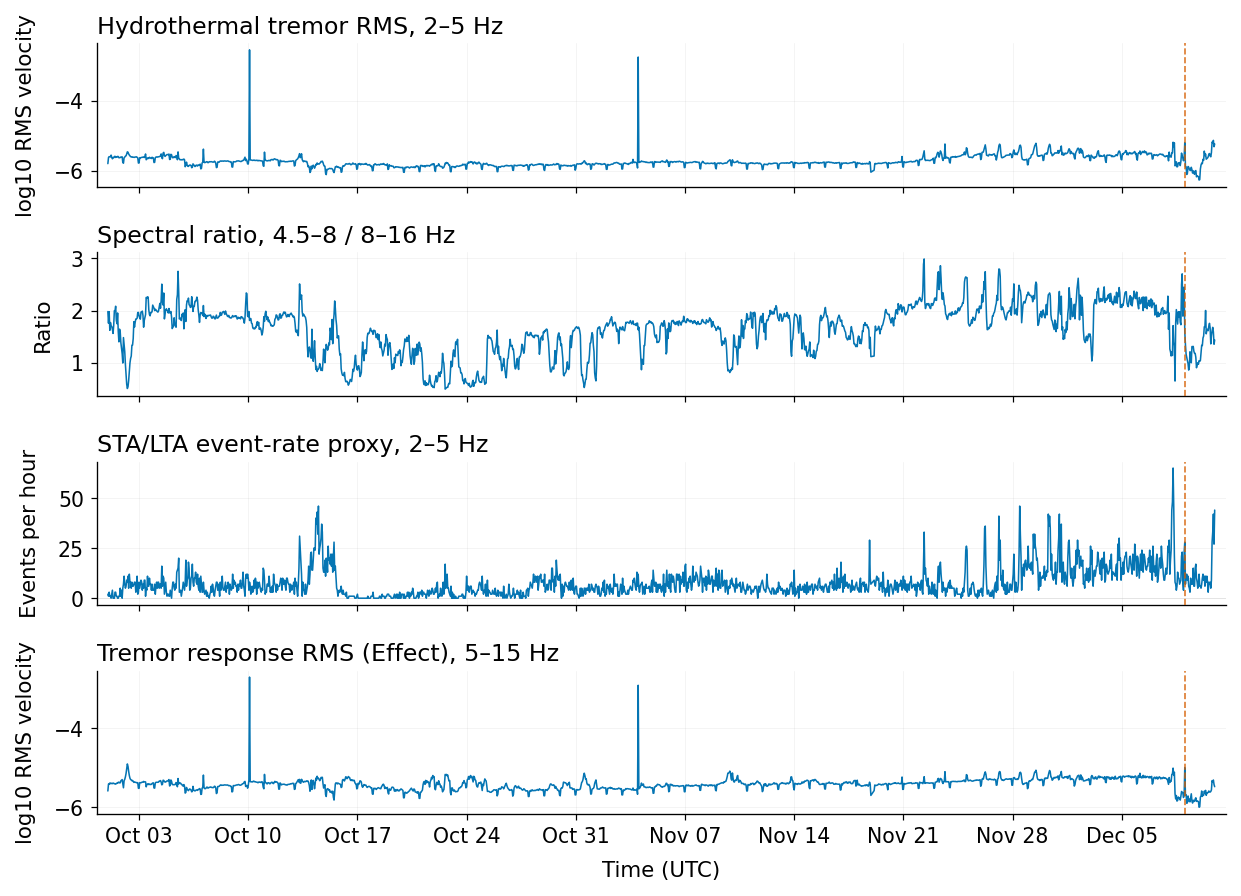

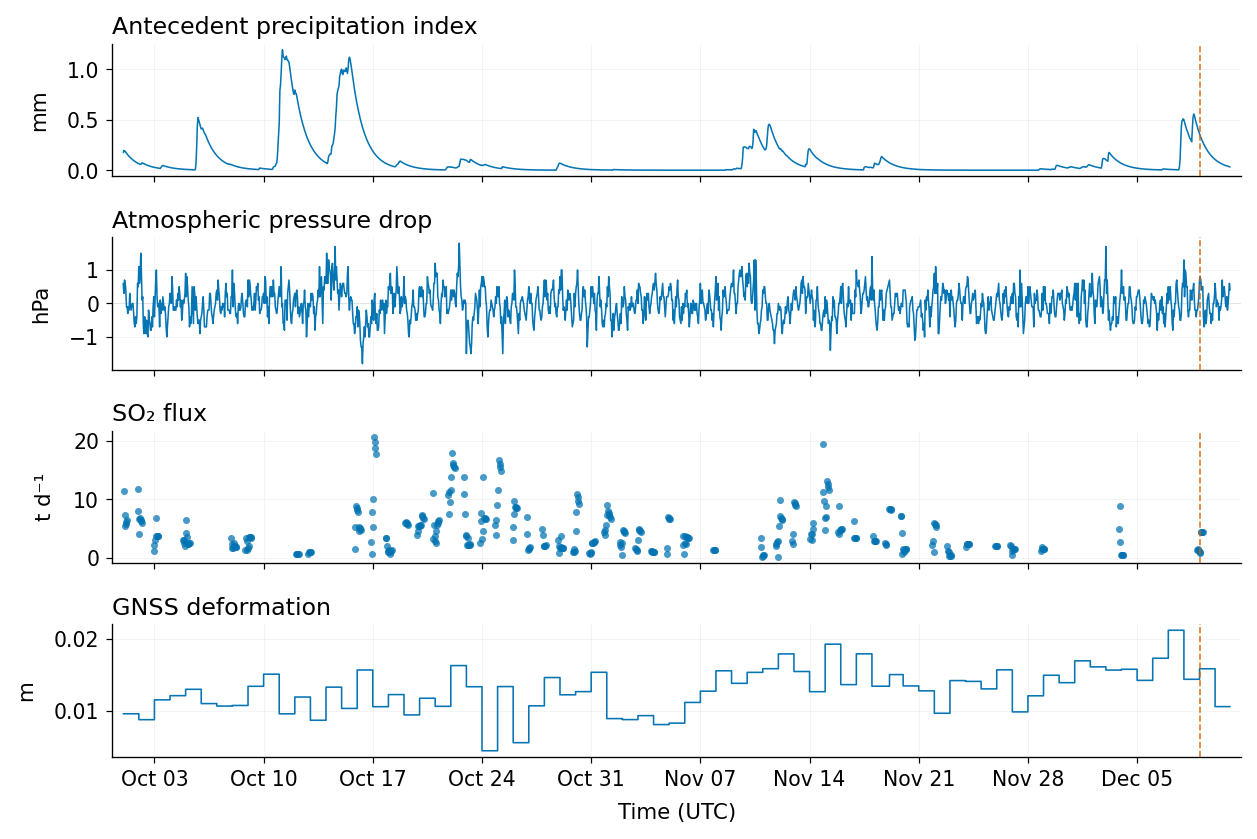

((<Figure size 1280x860.8 with 4 Axes>,
  array([<Axes: title={'left': 'Hydrothermal tremor RMS, 2–5 Hz'}, ylabel='log10 RMS velocity'>,
         <Axes: title={'left': 'Spectral ratio, 4.5–8 / 8–16 Hz'}, ylabel='Ratio'>,
         <Axes: title={'left': 'STA/LTA event-rate proxy, 2–5 Hz'}, ylabel='Events per hour'>,
         <Axes: title={'left': 'Tremor response RMS (Effect), 5–15 Hz'}, xlabel='Time (UTC)', ylabel='log10 RMS velocity'>],
        dtype=object)),
 (<Figure size 1280x796.8 with 4 Axes>,
  array([<Axes: title={'left': 'Antecedent precipitation index'}, ylabel='mm'>,
         <Axes: title={'left': 'Atmospheric pressure drop'}, ylabel='hPa'>,
         <Axes: title={'left': 'SO₂ flux'}, ylabel='t d⁻¹'>,
         <Axes: title={'left': 'GNSS deformation'}, xlabel='Time (UTC)', ylabel='m'>],
        dtype=object)))

In [9]:
plot_whakaari_thesis_figures(
    csv_path="../data/whakaari/whakaari_raw.csv",
    eruption_time=WHAKAARI_ERUPTION_TIME,
    save_dir="figures",
    include_titles=False,
    display_transform={
        "hydro_2_5": "log10",
        "effect_tremor_5_15": "log10",
    },
)

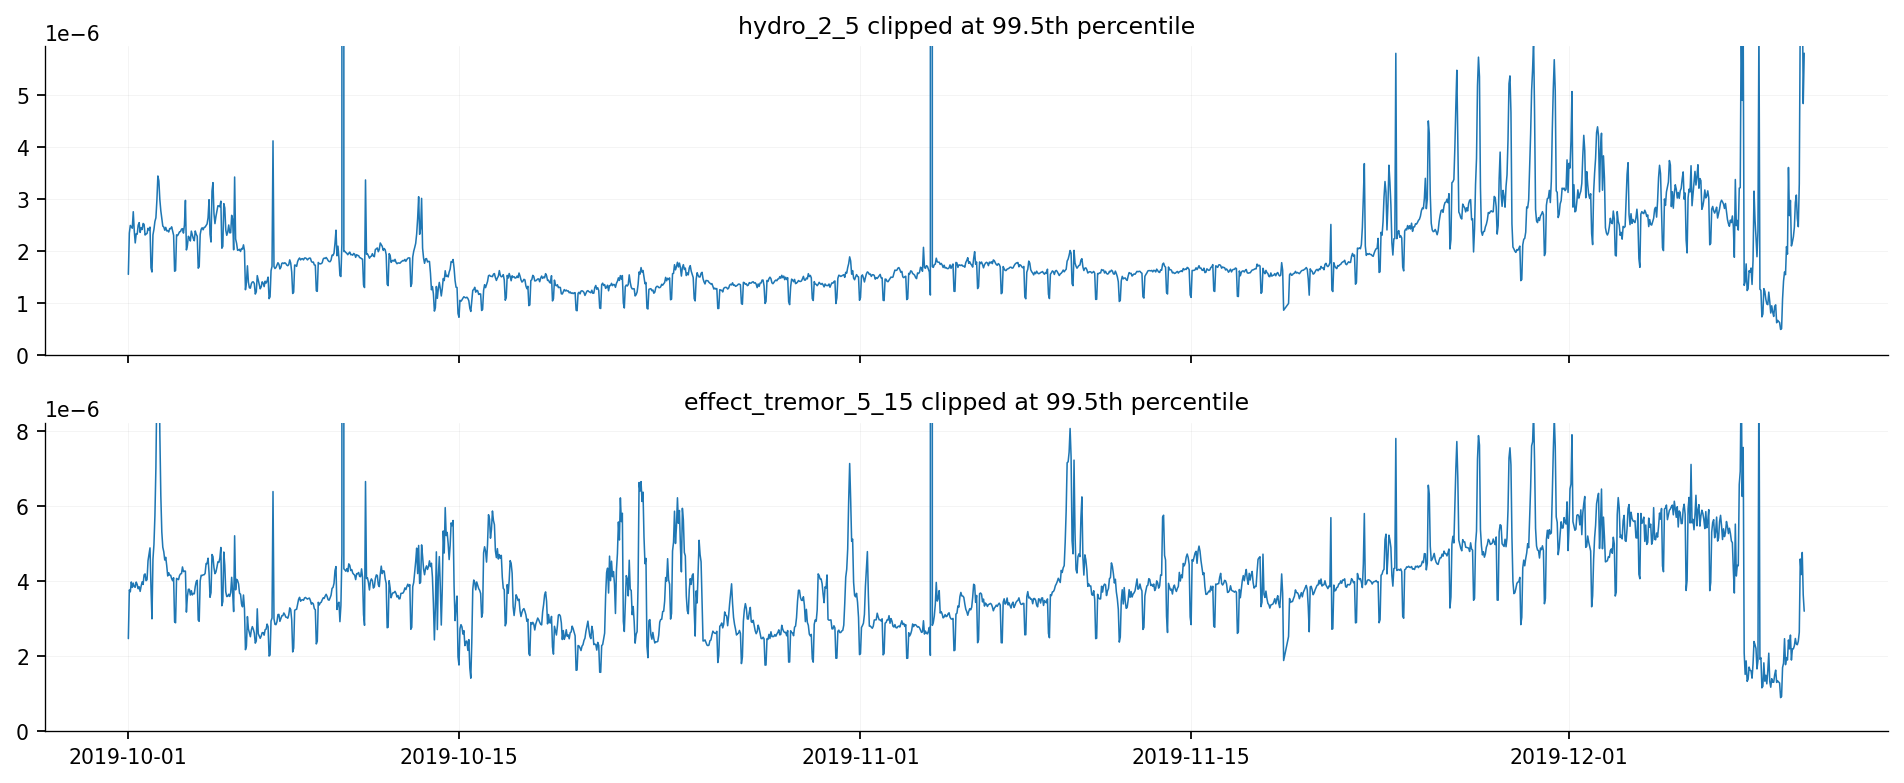

In [10]:
import matplotlib.pyplot as plt
cols = ["hydro_2_5", "effect_tremor_5_15"]

fig, axes = plt.subplots(len(cols), 1, figsize=(12, 5), sharex=True)

for ax, col in zip(axes, cols):
    y = whakaari_raw[col]
    ymax = y.quantile(0.995)

    ax.plot(whakaari_raw.index, y, linewidth=0.7)
    ax.set_ylim(0, ymax)
    ax.set_title(f"{col} clipped at 99.5th percentile")

plt.tight_layout()
plt.show()

## Geographic Visualization

c:\Users\cescedes\Desktop\Distinguishing Causes and Triggers in Volcanic and Seismic Processes\src\whakaari\whakaari_plotting_utils.py:743: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  label_rows = pd.concat([centres, reference_df], ignore_index=True)


,Source,Source ID,Variables,Internal names
0,Open-Meteo,WHAKAARI_OPENMETEO_PROXY,Antecedent precipitation index; Atmospheric pr...,"API, pressure_drop"
1,RGWC–RGWI GNSS,RGWC_RGWI,GNSS deformation proxy,GNSS_deformation
2,WID01 SO₂,WID01,SO₂ flux,SO2_flux
3,WSRZ,WSRZ,"Tremor response RMS, 5–15 Hz; High-frequency e...","effect_tremor_5_15, event_rate_2_5, hydro_2_5,..."


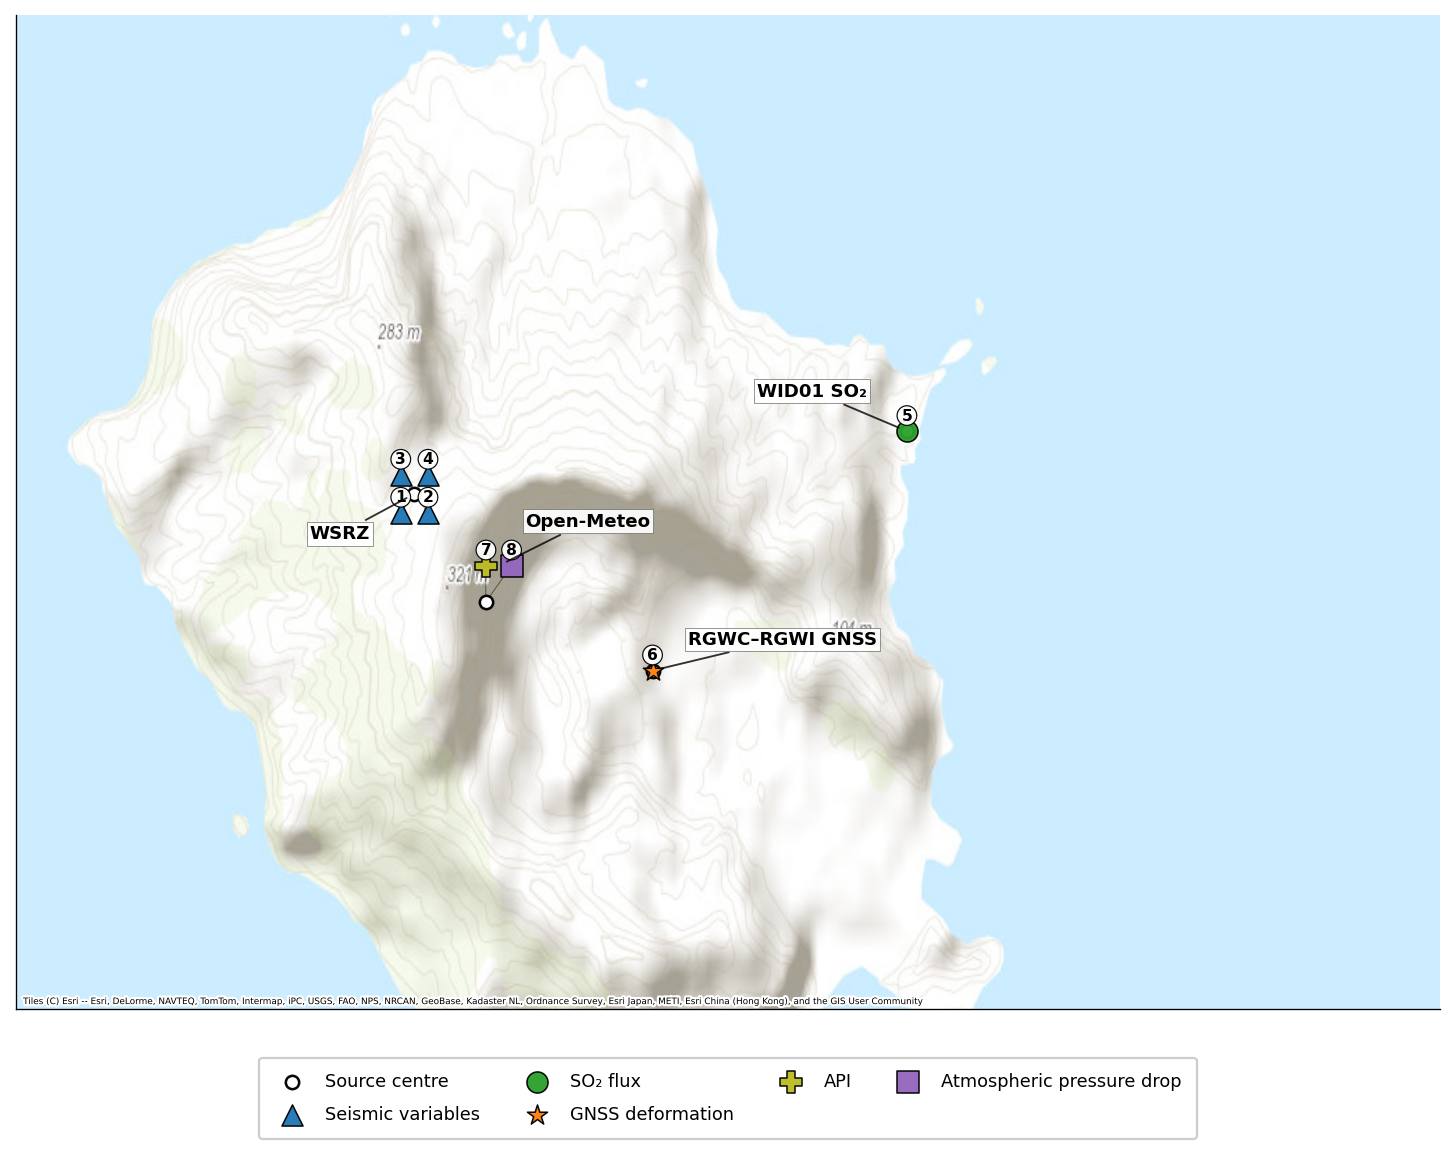

In [11]:
whakaari_meta = whakaari_observable_metadata()

fig, ax, whakaari_variable_table = plot_whakaari_all_variables_map(
    metadata=whakaari_meta,
    satellite=False,
    save_dir="figures",
    filename="whakaari_map",
)

whakaari_variable_table

c:\Users\cescedes\Desktop\Distinguishing Causes and Triggers in Volcanic and Seismic Processes\src\whakaari\whakaari_plotting_utils.py:743: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  label_rows = pd.concat([centres, reference_df], ignore_index=True)


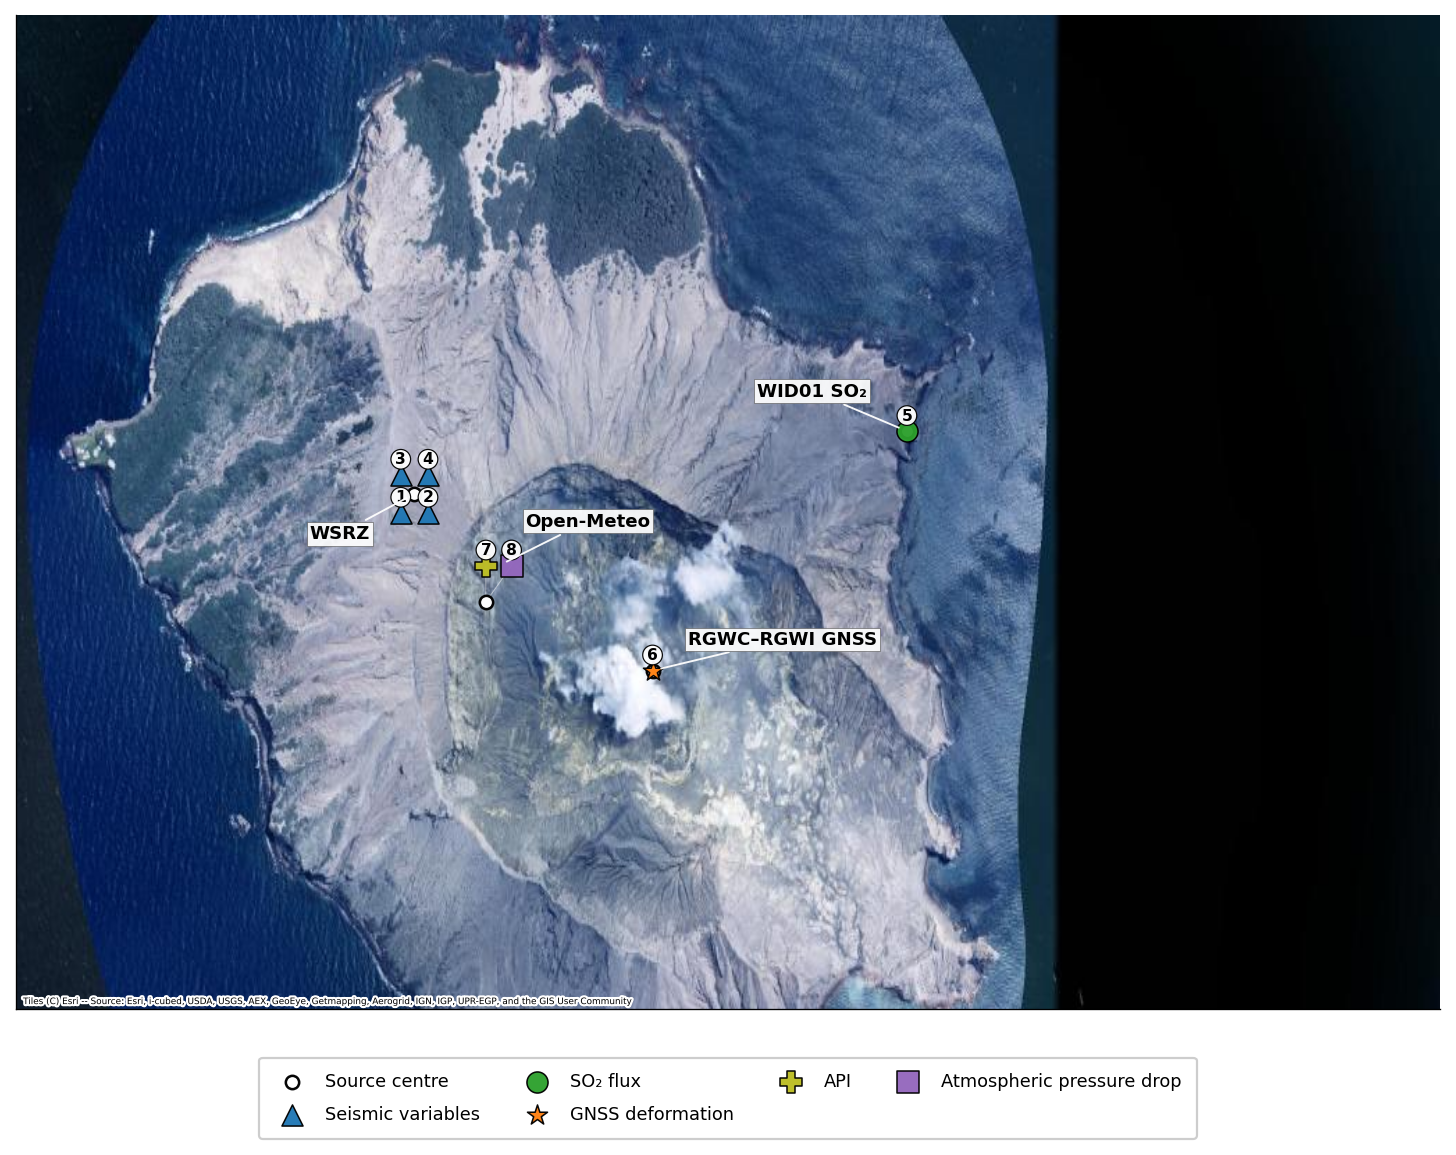

In [12]:
fig, ax, whakaari_variable_table = plot_whakaari_all_variables_map(
    metadata=whakaari_meta,
    satellite=True,
    save_dir="figures",
    filename="whakaari_satellite",
)